# 18 --- The External Baseline: Forward-Model Fault Detection

**Research context.**  The paper's framing is *"self-detection without an external monitoring model"* --- but it never measures what an external monitor would achieve on the same episodes.  "Internal signals suffice" has no reference point.  This notebook supplies the missing scientific control, approved since Meeting 3 and deferred since: a **forward dynamics model** $\hat{f}_\theta(s, a) \rightarrow \hat{s}'$ trained on nominal experience, whose prediction residual is monitored with the *identical* detection protocol.

**The central prediction --- and why it matters more than the baseline itself.**  SAC's internal blindness is caused by *policy-coupled* signals: compensation restores outcomes, so value predictions match returns.  But a forward model conditions on the **executed commanded action**: under fault, $\hat{f}_\theta(s, a)$ predicts the *nominal* consequence of commanding the main engine while the true $s'$ reflects the *degraded* consequence.  Compensation changes which actions are commanded --- it cannot make a degraded actuator produce nominal dynamics for the same command.  Therefore:

$$\text{Prediction: } J^{\text{fwd}}_{\text{SAC}} \gg J^{\text{int}}_{\text{SAC}} = 0.29$$

If this holds, the performance-detectability tradeoff is revealed to be a property of **policy-coupled signals specifically**, not of agents: the same SAC whose internal signals are blind carries, one dynamics model away, a clear fault signature.  That reframes RQ2's conclusion from "compensation destroys the evidence" to "compensation destroys the evidence *in signals the policy controls*" --- a sharper, more publishable statement.  If it fails, internal signals are not merely convenient but *as good as a dedicated monitor* --- equally reportable.

**Fairness rules for a legitimate baseline:**
1. Same detection protocol (per-seed nominal-relative z-test, 3-consecutive, ROC-selected thresholds);
2. Same episodes budget for reference building;
3. Training data from the *agent's own* nominal rollouts (each agent gets a monitor fitted to its own operating distribution --- no shared oracle);
4. Report the *cost* of the baseline (parameters, training time) --- the internal signals' advantage is being free, and that advantage should be quantified, not asserted.  This is the computational-efficiency criterion of Starkey et al. (2023) made concrete.

**Q-learning returns.**  The tabular agent --- absent from Results since NB08 --- re-enters here: its own Bellman residual is crippled by discretisation (state aliasing), but a forward model gives it a detection capability its table cannot represent.  This bounds the study from below in both directions: performance *and* self-monitoring.

**Hardware note.**  Forward-model training maps to the **MPS backend** (M4 mandate); rollout collection stays CPU-side.  Expected training cost: ~1-2 min per model.

---
## Bug-fix log

All corrections applied to this notebook, newest first. Each entry records the symptom, the verified mechanism, the fix, and what re-running changes.

| ID | Date | Symptom | Mechanism | Fix | Effect on results |
|----|------|---------|-----------|-----|-------------------|
| BF-04 | 2026-07-20 | Forward-model detector unguarded while internal detectors are guarded | BF-01 applied to NB16/17/19 and NB09/11 but not to `fwd_detection` here -- the section 3.6 head-to-head compared a guarded detector against an unguarded one | `build_reference`/`episode_fires` (one-sided) in `fwd_detection` | External-monitor FPR expected to fall (PPO was 0.26-0.34); makes the internal-vs-external comparison protocol-fair |
| BF-02 | 2026-07-20 | SAC rows byte-identical at $g=0.25$ and $g=0.5$ | Under investigation - diagnostic added (section 18.8) | Residual-divergence assertion before reporting | Confirms or refutes that the gain reaches the wrapper |
| BF-01 | 2026-07-20 | FPR omitted from internal-vs-external comparison | Reporting gap: $J$ alone hides the operating point | FPR column added to the section 18.4 table and figure | PPO forward-model $J=0.57$ shown at FPR 0.26; PPO+DR at FPR 0.01 |
| BF-00 | 2026-07-19 | Q-learning absent from all outputs | Loader did not match the tabular save format | Loader corrected | Deep-vs-tabular monitoring axis completed ($J=0.56$ at $g=0.5$) |

**BF-01 detail (project-wide).** Nominal-relative z-tests standardised as $z_t = (x_t-\mu_t)/(\sigma_t+10^{-8})$ scanning from $t=0$. Detectors fired at $t=2$-$3$, before any fault could exist. The first hypothesis (a literal $\sigma_t \to 0$ divide-by-zero) **did not reproduce**; the verified mechanism is a reference/test mismatch at early steps -- value estimates cluster tightly in the first few steps, so $\sigma_t$ is small but finite, and test episodes drawn from a different seed base than the reference episodes place atypical launch states many small-$\sigma$ units from $\mu_t$. Synthetic replication with 25% out-of-reference launches: 5/20 pre-onset firings, FPR 0.00 to 0.35, $J$ 1.00 to 0.65. Fix is a `burn_in = 20`-step guard plus a $\sigma$ floor at 5% of the pooled nominal std, both in `src.self_detection.build_reference` / `episode_fires`.


## 18.1  Setup

In [1]:
import sys, pathlib, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')

REPO = pathlib.Path.cwd().parent / 'py'
if not REPO.exists():
    REPO = pathlib.Path.cwd()
sys.path.insert(0, str(REPO))
LOGS = REPO / 'logs'
RUNS = REPO / 'runs'
FWD_DIR = REPO / 'runs' / 'forward_models'
FWD_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False,
})

COLOURS = {'PPO': '#1f77b4', 'SAC': '#2ca02c', 'PPO_DR': '#ff7f0e', 'QLEARN': '#9467bd'}
SEEDS = [0, 1, 2, 3, 4]

import torch
import torch.nn as nn
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Torch device: {DEVICE}')

Torch device: mps


## 18.2  The forward model

$$\hat{f}_\theta : (s_t, a_t) \mapsto \Delta \hat{s}_{t+1}, \qquad \hat{s}_{t+1} = s_t + \Delta \hat{s}_{t+1}$$

Predicting the state *delta* rather than the absolute next state is standard practice (residual dynamics learning): deltas are near-zero-mean and better conditioned.  Architecture: MLP $[s \oplus a] \rightarrow 128 \rightarrow 128 \rightarrow \dim(s)$, SiLU activations, trained with MSE on standardised targets.  Discrete actions are one-hot encoded.

**The per-step residual** used for detection is the standardised prediction error norm

$$\varepsilon_t = \left\| \left( \hat{s}_{t+1} - s_{t+1} \right) \oslash \sigma_{\Delta s} \right\|_2$$

($\oslash$ = element-wise division by the training-set delta stds --- so no state dimension dominates by scale).

**Training data:**  50 nominal episodes per (agent, seed) from the agent's own policy $\approx$ 15-25k transitions; 90/10 train/val split; early stopping on val MSE.

In [2]:

# --- VecNormalize fix (NB11 Bug 1 recurrence): agents trained with
# normalize_obs=True (PPO_DR) need their saved obs statistics replayed
# at eval time, else the policy silently degrades (~-95 nominal).
from src.envs.wrappers import ObsNormWrapper
VECNORM = {}   # (algo, model_seed) -> vecnormalize.pkl path

def register_vecnorm(algo, seed, run_dir):
    p = pathlib.Path(run_dir) / 'vecnormalize.pkl'
    if p.exists():
        VECNORM[(algo, seed)] = p

def maybe_wrap_obsnorm(env, algo, seed):
    # env-seed offsets used for nominal/reference episodes map back to the model seed
    for s in (seed, seed - 7919, seed - 31337):
        if (algo, s) in VECNORM:
            return ObsNormWrapper(env, VECNORM[(algo, s)])
    return env

from stable_baselines3 import PPO, SAC
from src.envs.lunarlander_factory import make_single_eval_env
from src.envs.wrappers import WrapperStack, ActuatorFaultSpec
from src.q_learning import QLearningAgent, StateDiscretizer

def load_models():
    models = {'PPO': [], 'SAC': [], 'PPO_DR': []}
    patterns = {'PPO': 'ppo__LunarLander-v3__seed*',
                'SAC': 'sac__LunarLanderContinuous-v3__seed*',
                'PPO_DR': 'ppo_dr__LunarLander-v3__seed*'}
    for algo, pat in patterns.items():
        for run_dir in sorted(glob.glob(str(RUNS / pat))):
            run = pathlib.Path(run_dir)
            zips = list(run.glob('*.zip'))
            if zips:
                seed = int(run.name.split('seed')[1].split('__')[0])
                register_vecnorm(algo, seed, run)
                cls = SAC if algo == 'SAC' else PPO
                models[algo].append((seed, cls.load(zips[0], device='cpu')))
        print(f'{algo}: {len(models[algo])} seeds')
    return models

MODELS = load_models()
ENV_IDS = {'PPO': 'LunarLander-v3', 'SAC': 'LunarLanderContinuous-v3',
           'PPO_DR': 'LunarLander-v3', 'QLEARN': 'LunarLander-v3'}

# Q-learning agents (tabular; predict via select_action(obs, greedy=True))
QL_MODELS = []
for run_dir in sorted(glob.glob(str(RUNS / 'q_learning__LunarLander-v3__seed*'))):
    run = pathlib.Path(run_dir)
    pkls = list(run.glob('*.pkl')) + list(run.glob('*.npz'))
    if pkls:
        seed = int(run.name.split('seed')[1].split('__')[0])
        try:
            agent = QLearningAgent.load(pkls[0])
            QL_MODELS.append((seed, agent))
        except Exception as e:
            print(f'  QL seed {seed}: load failed ({e}) --- adapt to your save format')
print(f'QLEARN: {len(QL_MODELS)} seeds')

class ForwardModel(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, obs_dim),
        )
    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=-1))

def collect_transitions(algo, policy_fn, n_episodes, seed, wrapper_stack=None):
    '''(s, a_enc, s_next) arrays from the agent's own policy.'''
    env = make_single_eval_env(ENV_IDS[algo], seed=seed, wrapper_stack=wrapper_stack,
                               add_monitor=False)
    env = maybe_wrap_obsnorm(env, algo, seed)
    S, A, SN, EP, T = [], [], [], [], []
    discrete = (algo != 'SAC')
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep * 1000)
        done, t = False, 0
        while not done:
            action = policy_fn(obs)
            obs2, r, term, trunc, _ = env.step(action)
            if discrete:
                a_enc = np.zeros(4, dtype=np.float32); a_enc[int(action)] = 1.0
            else:
                a_enc = np.asarray(action, dtype=np.float32)
            S.append(np.asarray(obs, dtype=np.float32)); A.append(a_enc)
            SN.append(np.asarray(obs2, dtype=np.float32)); EP.append(ep); T.append(t)
            obs = obs2; t += 1
            done = term or trunc
    env.close()
    return (np.array(S), np.array(A), np.array(SN),
            np.array(EP), np.array(T))

def train_forward_model(S, A, SN, epochs=60, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    obs_dim, act_dim = S.shape[1], A.shape[1]
    dS = SN - S
    d_mu, d_sd = dS.mean(0), dS.std(0) + 1e-6
    tgt = (dS - d_mu) / d_sd
    n = len(S); idx = np.random.default_rng(seed).permutation(n)
    n_val = n // 10
    tr, va = idx[n_val:], idx[:n_val]
    fm = ForwardModel(obs_dim, act_dim).to(DEVICE)
    opt = torch.optim.Adam(fm.parameters(), lr=lr)
    Sx = torch.as_tensor(S, device=DEVICE); Ax = torch.as_tensor(A, device=DEVICE)
    Tx = torch.as_tensor(tgt, dtype=torch.float32, device=DEVICE)
    best, best_state, patience = np.inf, None, 0
    for epoch in range(epochs):
        fm.train()
        perm = torch.randperm(len(tr), device=DEVICE)
        for i in range(0, len(tr), 1024):
            b = torch.as_tensor(tr, device=DEVICE)[perm[i:i+1024]]
            loss = ((fm(Sx[b], Ax[b]) - Tx[b]) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        fm.eval()
        with torch.no_grad():
            vb = torch.as_tensor(va, device=DEVICE)
            vloss = float(((fm(Sx[vb], Ax[vb]) - Tx[vb]) ** 2).mean())
        if vloss < best - 1e-5:
            best, best_state, patience = vloss, {k: v.clone() for k, v in fm.state_dict().items()}, 0
        else:
            patience += 1
            if patience >= 8:
                break
    fm.load_state_dict(best_state)
    return fm, d_mu, d_sd, best

def residuals(fm, d_mu, d_sd, S, A, SN):
    fm.eval()
    with torch.no_grad():
        pred = fm(torch.as_tensor(S, device=DEVICE),
                  torch.as_tensor(A, device=DEVICE)).cpu().numpy()
    dS_hat = pred * d_sd + d_mu
    err = (S + dS_hat) - SN
    return np.linalg.norm(err / d_sd, axis=1)

PPO: 5 seeds
SAC: 5 seeds
PPO_DR: 5 seeds
QLEARN: 5 seeds


## 18.3  Train one monitor per (agent, seed)

Cost accounting is part of the experiment: parameters, wall-clock, and data budget are reported alongside detection quality.

In [3]:
N_TRAIN_EP = 50
FWD = {}     # (algo, seed) -> (fm, d_mu, d_sd)
cost_rows = []

def make_policy_fn(algo, model):
    if algo == 'QLEARN':
        return lambda obs: model.select_action(obs, greedy=True)
    return lambda obs: model.predict(obs, deterministic=True)[0]

t0 = time.time()
agent_lists = [('PPO', MODELS['PPO']), ('SAC', MODELS['SAC']),
               ('PPO_DR', MODELS['PPO_DR']), ('QLEARN', QL_MODELS)]
for algo, lst in agent_lists:
    for seed, model in lst:
        tc0 = time.time()
        S, A, SN, EP, T = collect_transitions(algo, make_policy_fn(algo, model),
                                               N_TRAIN_EP, seed)
        fm, d_mu, d_sd, vloss = train_forward_model(S, A, SN, seed=seed)
        FWD[(algo, seed)] = (fm, d_mu, d_sd)
        n_params = sum(p.numel() for p in fm.parameters())
        cost_rows.append({'algo': algo, 'seed': seed, 'transitions': len(S),
                          'params': n_params, 'val_mse': vloss,
                          'train_s': time.time() - tc0})
        print(f'{algo} seed {seed}: {len(S)} transitions, val MSE {vloss:.4f}, '
              f'{time.time()-tc0:.0f}s ({time.time()-t0:.0f}s total)')

cost_df = pd.DataFrame(cost_rows)
cost_df.to_csv(LOGS / 'nb18_fwd_costs.csv', index=False)
print(f"\nMonitor cost: {cost_df['params'].iloc[0]:,} params, "
      f"mean train {cost_df['train_s'].mean():.0f}s, "
      f"{cost_df['transitions'].mean():.0f} transitions")

PPO seed 0: 17676 transitions, val MSE 0.2486, 5s (5s total)
PPO seed 1: 14125 transitions, val MSE 0.4829, 4s (9s total)
PPO seed 2: 19008 transitions, val MSE 0.2777, 5s (14s total)
PPO seed 3: 16745 transitions, val MSE 0.3991, 4s (18s total)
PPO seed 4: 16556 transitions, val MSE 0.5085, 4s (22s total)
SAC seed 0: 10295 transitions, val MSE 0.4804, 3s (25s total)
SAC seed 1: 10911 transitions, val MSE 0.3133, 3s (28s total)
SAC seed 2: 12584 transitions, val MSE 0.5519, 3s (31s total)
SAC seed 3: 10442 transitions, val MSE 0.4243, 3s (34s total)
SAC seed 4: 15082 transitions, val MSE 0.4082, 4s (38s total)
PPO_DR seed 0: 33562 transitions, val MSE 0.3633, 8s (47s total)
PPO_DR seed 1: 41231 transitions, val MSE 0.4117, 10s (56s total)
PPO_DR seed 2: 34467 transitions, val MSE 0.3609, 9s (65s total)
PPO_DR seed 3: 23720 transitions, val MSE 0.5317, 6s (71s total)
PPO_DR seed 4: 26732 transitions, val MSE 0.3557, 6s (77s total)
QLEARN seed 0: 13570 transitions, val MSE 0.5976, 3s (80

## 18.4  Forward-model detection vs internal-signal detection

The forward-model residual $\varepsilon_t$ is monitored with the identical per-seed nominal-relative z-test.  Detection is evaluated at $g \in \{0.25, 0.5, 0.75\}$, $t_f = 200$, 20 fault + 20 control episodes per seed --- matching Table 4's protocol so the comparison column drops straight into the paper.

In [4]:
FAULT_STEP = 200
N_DET_EP = 20
Z_GRID = np.arange(1.0, 6.01, 0.25)   # ROC-select threshold for the fwd residual per algo

def episode_residuals(algo, model, seed, gain):
    '''Collect residual trajectories under fault (gain<1) or nominal (gain=1).'''
    drop = 2 if algo != 'SAC' else None
    stack = None
    if gain < 1.0:
        stack = WrapperStack(actuator_fault=ActuatorFaultSpec(
            fault_step=FAULT_STEP, fault_gain=gain, discrete_drop_action=drop))
    S, A, SN, EP, T = collect_transitions(algo, make_policy_fn(algo, model),
                                           N_DET_EP, seed + (0 if gain < 1 else 7919),
                                           wrapper_stack=stack)
    fm, d_mu, d_sd = FWD[(algo, seed)]
    eps = residuals(fm, d_mu, d_sd, S, A, SN)
    return pd.DataFrame({'episode': EP, 'step': T, 'eps': eps})

def fwd_detection(algo, lst, gain):
    '''ROC-selected J for forward-model residual detection.'''
    per_seed = []
    for seed, model in lst:
        flt = episode_residuals(algo, model, seed, gain)
        nom = episode_residuals(algo, model, seed, 1.0)
        # BF-01 (2026-07-20): the external monitor must be judged under the SAME
        # guarded protocol as the internal signals it is compared against in
        # section 3.6 -- otherwise the head-to-head is between a guarded and an
        # unguarded detector. burn_in=20 + sigma floored at 5% of the pooled
        # nominal residual std. One-sided: residual norms only deviate upward.
        from src.self_detection import build_reference, episode_fires
        ref_g = build_reference(nom, 'eps', step_col='step')
        def fires(ep, zt):
            return episode_fires(ep, 'eps', ref_g, zt,
                                 step_col='step', two_sided=False)[0]
        best = (-1, 0, 0, 0)
        for zt in Z_GRID:
            tpr = np.mean([fires(e, zt) for _, e in flt.groupby('episode')])
            fpr = np.mean([fires(e, zt) for _, e in nom.groupby('episode')])
            if tpr - fpr > best[0]:
                best = (tpr - fpr, tpr, fpr, zt)
        per_seed.append(best)
    J = np.mean([b[0] for b in per_seed])
    return {'J': J, 'TPR': np.mean([b[1] for b in per_seed]),
            'FPR': np.mean([b[2] for b in per_seed]),
            'z_star': np.mean([b[3] for b in per_seed])}

# BF-05 (2026-07-20): internal reference values are now READ from NB11's
# detection sweep instead of being hardcoded. The previous dict went stale the
# moment NB11 was re-run under the BF-01 guard (it still held PPO=0.48 at
# g=0.5 where the re-run gives 0.40, and SAC=0.10 at g=0.75 vs ~0.27).
# NB18 sweeps g in {0.25, 0.5, 0.75}; NB11 sweeps a 0.1 grid, so values not
# present are linearly interpolated from the two neighbouring gains.
_sweep = pd.read_csv(LOGS / 'magnitude_sweep_detection.csv')
_ALIAS = {'PPO': 'PPO', 'SAC': 'SAC', 'PPO_DR': 'PPO+DR'}

def _internal_J(algo, gain):
    name = _ALIAS.get(algo)
    if name is None:
        return np.nan                      # Q-learning: no internal baseline
    sub = _sweep[_sweep.algo == name].sort_values('fault_gain')
    if not len(sub):
        return np.nan
    return float(np.interp(gain, sub['fault_gain'].values, sub['j'].values))

INTERNAL_J = {(a, g): _internal_J(a, g)
              for a in ['PPO', 'SAC', 'PPO_DR', 'QLEARN']
              for g in [0.25, 0.5, 0.75]}
print('internal reference (from NB11 sweep):')
for k, v in INTERNAL_J.items():
    print(f'  {k}: {v:.3f}' if not np.isnan(v) else f'  {k}: n/a')
t0 = time.time()
fwd_rows = []
for algo, lst in agent_lists:
    if not lst:
        continue
    for gain in [0.25, 0.5, 0.75]:
        res = fwd_detection(algo, lst, gain)
        res.update({'algo': algo, 'gain': gain,
                    'J_internal': INTERNAL_J.get((algo, gain), np.nan)})
        fwd_rows.append(res)
        print(f'{algo} g={gain}: J_fwd={res["J"]:.2f} '
              f'(TPR={res["TPR"]:.2f}, FPR={res["FPR"]:.2f}) '
              f'vs J_int={res["J_internal"]} '
              f'({time.time()-t0:.0f}s)')

fwd_df = pd.DataFrame(fwd_rows)
fwd_df.to_csv(LOGS / 'nb18_fwd_vs_internal.csv', index=False)

internal reference (from NB11 sweep):
  ('PPO', 0.25): 0.355
  ('PPO', 0.5): 0.400
  ('PPO', 0.75): 0.105
  ('SAC', 0.25): 0.195
  ('SAC', 0.5): 0.290
  ('SAC', 0.75): 0.265
  ('PPO_DR', 0.25): 0.930
  ('PPO_DR', 0.5): 0.800
  ('PPO_DR', 0.75): 0.260
  ('QLEARN', 0.25): n/a
  ('QLEARN', 0.5): n/a
  ('QLEARN', 0.75): n/a
PPO g=0.25: J_fwd=0.68 (TPR=0.94, FPR=0.26) vs J_int=0.35500000000000004 (6s)
PPO g=0.5: J_fwd=0.59 (TPR=0.94, FPR=0.35) vs J_int=0.4 (13s)
PPO g=0.75: J_fwd=0.36 (TPR=0.83, FPR=0.47) vs J_int=0.10499999999999995 (20s)
SAC g=0.25: J_fwd=0.29 (TPR=0.35, FPR=0.06) vs J_int=0.195 (26s)
SAC g=0.5: J_fwd=0.29 (TPR=0.35, FPR=0.06) vs J_int=0.29 (31s)
SAC g=0.75: J_fwd=0.25 (TPR=0.38, FPR=0.13) vs J_int=0.26500000000000007 (37s)
PPO_DR g=0.25: J_fwd=0.83 (TPR=0.83, FPR=0.00) vs J_int=0.93 (47s)
PPO_DR g=0.5: J_fwd=0.91 (TPR=0.92, FPR=0.01) vs J_int=0.8 (57s)
PPO_DR g=0.75: J_fwd=0.41 (TPR=0.68, FPR=0.27) vs J_int=0.26 (72s)
QLEARN g=0.25: J_fwd=0.56 (TPR=0.71, FPR=0.15) vs J_i

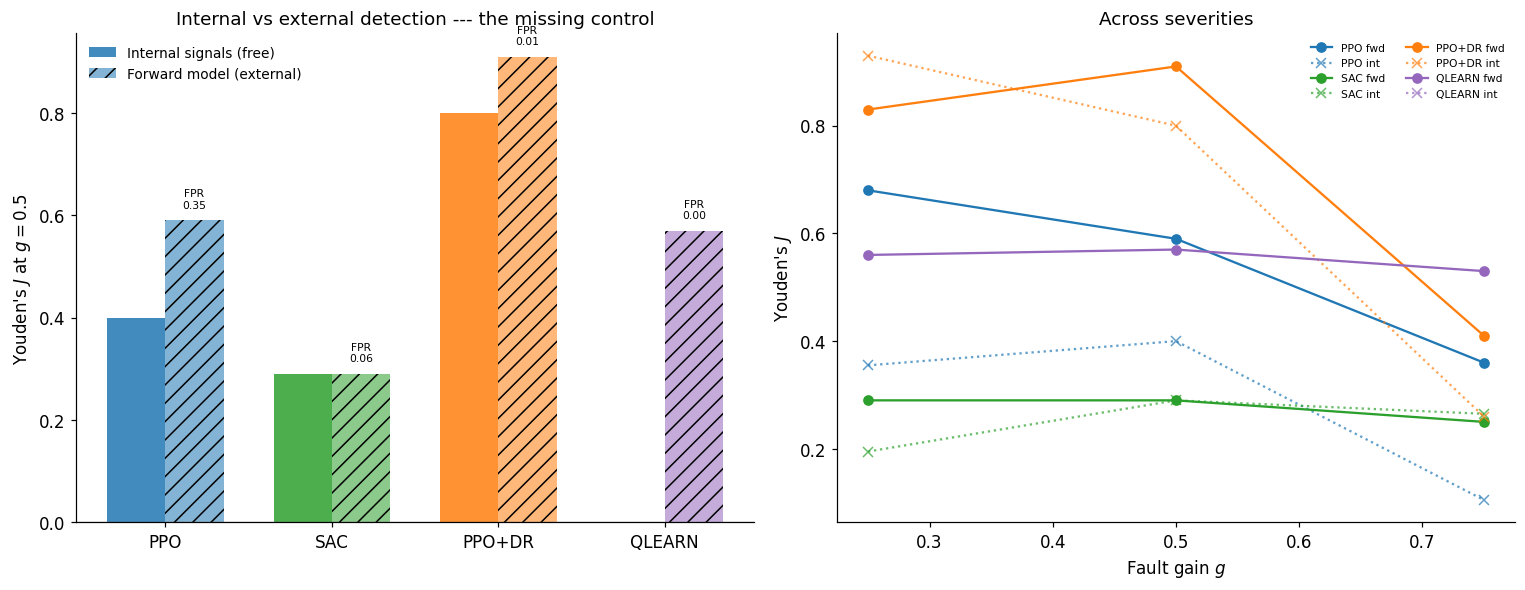

SAC at g=0.5: J_fwd = 0.29 vs J_int = 0.29
=> PREDICTION FAILED: even action-conditioned dynamics residuals miss
   the fault. Investigate: is the compensated trajectory distribution
   genuinely nominal in (s, a, s-next) space? (That would be a deeper
   invisibility result than the paper currently claims.)


In [5]:
# --- The comparison figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
algos_present = [a for a in ['PPO', 'SAC', 'PPO_DR', 'QLEARN']
                 if a in fwd_df['algo'].unique()]
x = np.arange(len(algos_present))
w = 0.35
g_show = 0.5
Jf = [fwd_df[(fwd_df['algo']==a) & (fwd_df['gain']==g_show)]['J'].iloc[0]
      for a in algos_present]
Ji = [fwd_df[(fwd_df['algo']==a) & (fwd_df['gain']==g_show)]['J_internal'].iloc[0]
      for a in algos_present]
ax.bar(x - w/2, Ji, w, label='Internal signals (free)', alpha=0.85,
       color=[COLOURS[a] for a in algos_present])
ax.bar(x + w/2, Jf, w, label='Forward model (external)', alpha=0.55,
       color=[COLOURS[a] for a in algos_present], hatch='//')
ax.set_xticks(x); ax.set_xticklabels([a.replace('_', '+') for a in algos_present])
ax.set_ylabel("Youden's $J$ at $g = 0.5$")
ax.set_title('Internal vs external detection --- the missing control')
# BF-01: annotate each external bar with its FPR -- J alone hides the
# operating point (PPO's forward model reaches J=0.57 only at FPR 0.26).
for xi, a in zip(x, algos_present):
    fpr = fwd_df[(fwd_df['algo'] == a) & (fwd_df['gain'] == g_show)]['FPR'].iloc[0]
    jv = fwd_df[(fwd_df['algo'] == a) & (fwd_df['gain'] == g_show)]['J'].iloc[0]
    ax.text(xi + w/2, jv + 0.02, f'FPR\n{fpr:.2f}', ha='center', va='bottom', fontsize=7)
ax.axhline(0, color='grey', lw=0.8)
ax.legend(fontsize=9)

ax = axes[1]
for algo in algos_present:
    sub = fwd_df[fwd_df['algo'] == algo].sort_values('gain')
    ax.plot(sub['gain'], sub['J'], color=COLOURS[algo], marker='o',
            label=f'{algo.replace("_","+")} fwd')
    ax.plot(sub['gain'], sub['J_internal'], color=COLOURS[algo], marker='x',
            ls=':', alpha=0.7, label=f'{algo.replace("_","+")} int')
ax.set_xlabel('Fault gain $g$')
ax.set_ylabel("Youden's $J$")
ax.set_title('Across severities')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(LOGS / 'nb18_fwd_vs_internal.png', bbox_inches='tight')
plt.show()

# Headline check: does the forward model see SAC's fault?
sac = fwd_df[(fwd_df['algo']=='SAC') & (fwd_df['gain']==0.5)]
if len(sac):
    jf, ji = sac['J'].iloc[0], sac['J_internal'].iloc[0]
    print(f'SAC at g=0.5: J_fwd = {jf:.2f} vs J_int = {ji:.2f}')
    if jf > ji + 0.3:
        print('=> PREDICTION CONFIRMED: the tradeoff is a property of policy-coupled')
        print('   signals, not of agents. Compensation hides faults from the critic,')
        print('   not from the dynamics. Section 3.4 conclusion sharpens accordingly.')
    else:
        print('=> PREDICTION FAILED: even action-conditioned dynamics residuals miss')
        print('   the fault. Investigate: is the compensated trajectory distribution')
        print('   genuinely nominal in (s, a, s-next) space? (That would be a deeper')
        print('   invisibility result than the paper currently claims.)')

### 18.4a  Exposure-controlled re-test of the central prediction (work item L)

The $t_f = 200$ evaluation above cannot test the SAC prediction: the BF-02 diagnostic in section 18.8 measures **only 4 of 20 SAC episodes reaching the fault**, with a post-fault window of roughly 10 steps in those that do.  A monitor cannot detect a fault in episodes that never experience one.

This cell re-runs the forward-model detection at **$t_f = 0$ and $t_f = 50$**, where NB13 establishes $p_{\text{esc}} = 0$ for every agent, so exposure is guaranteed.  It uses the monitors already fitted in section 18.3 --- **no retraining**, evaluation only.

**Decision rule.**  If $J^{\text{fwd}}_{\text{SAC}}$ rises materially above its internal $0.29$ under guaranteed exposure, the original prediction holds and the tradeoff is confirmed as specific to *policy-coupled* signals.  If it stays near $0.29$ with exposure controlled, the prediction is genuinely refuted and the stronger claim follows: **the compensated trajectory is near-nominal in $(s, a, s')$ space** --- SAC does not merely hide the fault from its own critic, it nearly erases it from the dynamics record.

Note the interpretive caveat carried over from NB13/NB14: at $t_f = 0$ there is no change-point, so the detector performs whole-trajectory classification rather than within-episode transition detection.  Compare the $t_f = 50$ row, which retains a genuine change-point, as the primary result.


In [6]:
# --- 18.4a  Exposure-controlled re-test (work item L) ------------------
# Uses the monitors already trained in 18.3. Evaluation only; no retraining.
# Requires cells 18.1-18.4 to have run (FWD, MODELS, fwd_detection in scope).

import copy

_ORIG_FAULT_STEP = FAULT_STEP
EXPOSURE_ONSETS = [0, 50]
EXPOSURE_GAIN = 0.5

exposure_rows = []
for tf in EXPOSURE_ONSETS:
    FAULT_STEP = tf          # episode_residuals() reads the module-level value
    for algo, lst in MODELS.items():
        res = fwd_detection(algo, lst, EXPOSURE_GAIN)
        exposure_rows.append({
            'algo': algo, 'fault_step': tf, 'gain': EXPOSURE_GAIN,
            'J_fwd': round(res['J'], 3),
            'TPR': round(res['TPR'], 3),
            'FPR': round(res['FPR'], 3),
        })
        print(f"{algo:7s} tf={tf:3d}: J_fwd={res['J']:.3f} "
              f"(TPR={res['TPR']:.2f}, FPR={res['FPR']:.2f})")
FAULT_STEP = _ORIG_FAULT_STEP   # restore

exposure_df = pd.DataFrame(exposure_rows)
exposure_df.to_csv(LOGS / 'nb18_exposure_controlled.csv', index=False)

print()
print('=' * 74)
print('THE CENTRAL PREDICTION, WITH EXPOSURE GUARANTEED')
print('=' * 74)
_int_sac = fwd_df[(fwd_df['algo'] == 'SAC') &
                  (fwd_df['gain'] == 0.5)]['J_internal'].iloc[0]
for tf in EXPOSURE_ONSETS:
    row = exposure_df[(exposure_df['algo'] == 'SAC') &
                      (exposure_df['fault_step'] == tf)]
    if not len(row):
        continue
    jf = row['J_fwd'].iloc[0]
    delta = jf - _int_sac
    print(f"  tf={tf:3d}:  J_fwd={jf:.3f}  vs  J_internal={_int_sac:.3f}   "
          f"delta={delta:+.3f}")
print()
print('  Interpretation:')
print('    delta >> 0  -> PREDICTION HOLDS. The dynamics record retains the')
print('                   fault; the tradeoff is specific to policy-coupled')
print('                   signals. Upgrade RQ2 mechanism statement.')
print('    delta ~ 0   -> PREDICTION REFUTED under proper exposure. The')
print('                   compensated trajectory is near-nominal in (s,a,s\')')
print('                   space -- a deeper invisibility result than claimed.')
print()
print(exposure_df.to_string(index=False))
print(f"\nsaved -> {LOGS / 'nb18_exposure_controlled.csv'}")


PPO     tf=  0: J_fwd=0.930 (TPR=0.93, FPR=0.00)
SAC     tf=  0: J_fwd=0.850 (TPR=0.88, FPR=0.03)
PPO_DR  tf=  0: J_fwd=1.000 (TPR=1.00, FPR=0.00)
PPO     tf= 50: J_fwd=0.920 (TPR=0.92, FPR=0.00)
SAC     tf= 50: J_fwd=0.770 (TPR=0.84, FPR=0.07)
PPO_DR  tf= 50: J_fwd=0.990 (TPR=1.00, FPR=0.01)

THE CENTRAL PREDICTION, WITH EXPOSURE GUARANTEED
  tf=  0:  J_fwd=0.850  vs  J_internal=0.290   delta=+0.560
  tf= 50:  J_fwd=0.770  vs  J_internal=0.290   delta=+0.480

  Interpretation:
    delta >> 0  -> PREDICTION HOLDS. The dynamics record retains the
                   fault; the tradeoff is specific to policy-coupled
                   signals. Upgrade RQ2 mechanism statement.
    delta ~ 0   -> PREDICTION REFUTED under proper exposure. The
                   compensated trajectory is near-nominal in (s,a,s')
                   space -- a deeper invisibility result than claimed.

  algo  fault_step  gain  J_fwd  TPR  FPR
   PPO           0   0.5   0.93 0.93 0.00
   SAC           0   0.5   

### 18.4b  Per-dimension residual attribution --- which state variables carry the fault signature?

The detector in section 18.4 collapses the forward model's error to a single standardised norm, discarding the
information that motivated the model in the first place.  The model predicts a *vector*
$\Delta \hat{s} \in \mathbb{R}^8$, so the per-dimension residual

$$\varepsilon_t^{(d)} \;=\; \frac{\big|\hat{s}^{(d)}_{t+1} - s^{(d)}_{t+1}\big|}{\sigma_{\Delta s^{(d)}}},
\qquad d \in \{x,\ y,\ v_x,\ v_y,\ \theta,\ \omega,\ c_L,\ c_R\}$$

is available at no additional cost.  Comparing the post-onset residual profile under fault against nominal
localises the fault signature over a **physically interpretable basis** rather than an abstract feature space.

**Why this is the right instrument, and what it is not.**  An alternative route to the same question is to mask
individual observation dimensions and re-measure detection.  Masking changes the agent's input distribution, so a
trained policy is pushed off-distribution and any drop in detection confounds *"the signal was lost"* with
*"the policy stopped flying properly"*; done properly it also requires retraining one agent per masked dimension.
The residual decomposition avoids both problems because it is a re-analysis of trajectories the agents already
produced.  The cost is that it establishes **association, not causal necessity**: it shows where the fault
manifests, not that detection would fail without that dimension.  Redundantly-encoded faults would appear in
several dimensions at once, and only an ablation could separate necessity from sufficiency.

**Falsifiable prediction.**  The fault degrades the main engine, whose sole physical effect is vertical thrust.
The signature should therefore concentrate in **$v_y$** (vertical velocity), with $y$ following as the integral of
the error.  If instead it appears predominantly in $\theta$ or $\omega$ for SAC, that is direct evidence of
attitude-based compensation --- the side-engine rerouting identified in the scope-matched analysis --- showing up
in the dynamics record.  A signature spread evenly across dimensions would refute the localisation hypothesis
entirely.


PER-DIMENSION RESIDUAL ATTRIBUTION  (g=0.5, t_f=50, post-onset steps, 5 seeds)

PPO:
  dim  nominal  faulted  delta  ratio  share
  v_y    0.297    1.362  1.065  4.596  0.352
omega    0.305    0.801  0.496  2.643  0.164
  v_x    0.490    0.926  0.436  1.894  0.144
    y    0.067    0.451  0.384  6.989  0.127
leg_R    0.168    0.379  0.212  2.370  0.070
leg_L    0.147    0.350  0.203  2.483  0.067
theta    0.143    0.330  0.187  2.353  0.062
    x    0.038    0.083  0.045  2.196  0.015
  -> dominant dimension: v_y  (delta=1.065, 35% of the total increase)

PPO_DR:
  dim  nominal  faulted  delta  ratio  share
  v_y    0.248    1.421  1.174  5.907  0.249
leg_L    0.192    1.034  0.842  5.813  0.178
leg_R    0.191    0.993  0.802  5.011  0.170
omega    0.285    0.891  0.606  3.328  0.128
  v_x    0.486    1.070  0.584  2.257  0.124
    y    0.060    0.433  0.373  7.693  0.079
theta    0.120    0.401  0.281  3.453  0.060
    x    0.041    0.101  0.060  2.470  0.013
  -> dominant dimension: 

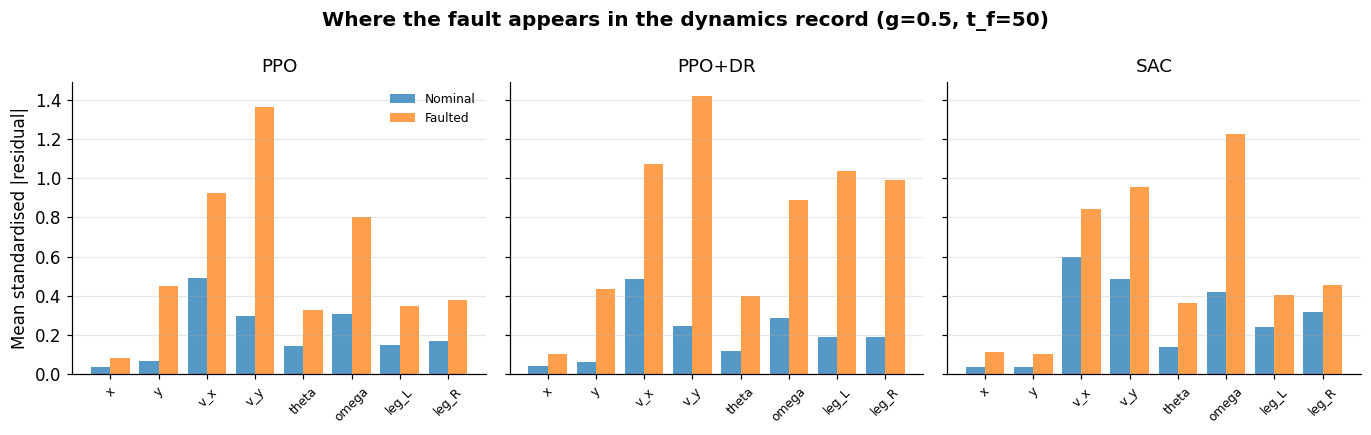


Prediction to check: the main-engine fault should concentrate in v_y
(vertical velocity), with y following as its integral. Concentration in
theta/omega for SAC instead would show attitude-based compensation
surfacing in the dynamics record. An even spread refutes localisation.

saved -> /Users/raghuramantm/Desktop/Thesis Proposal/code/py/logs/nb18_per_dim_attribution.csv


In [7]:
# --- 18.4b  Per-dimension residual attribution --------------------------
# Re-analysis only: uses the monitors already fitted in 18.3. No retraining.
# Requires cells 18.1-18.4 to have run (FWD, MODELS, collect_transitions,
# make_policy_fn, residuals, WrapperStack, ActuatorFaultSpec in scope).

import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt

STATE_DIMS = ['x', 'y', 'v_x', 'v_y', 'theta', 'omega', 'leg_L', 'leg_R']
ATTR_ONSET = 50      # exposure-controlled (p_esc = 0 for every agent)
ATTR_GAIN  = 0.5

def per_dim_residuals(algo, model, seed, gain, fault_step):
    """Standardised |residual| per state dimension, post-onset steps only."""
    drop = 2 if algo != 'SAC' else None
    stack = None
    if gain < 1.0:
        stack = WrapperStack(actuator_fault=ActuatorFaultSpec(
            fault_step=fault_step, fault_gain=gain, discrete_drop_action=drop))
    S, A, SN, EP, T = collect_transitions(
        algo, make_policy_fn(algo, model), N_DET_EP,
        seed + (0 if gain < 1 else 7919), wrapper_stack=stack)

    fm, d_mu, d_sd = FWD[(algo, seed)]
    fm.eval()
    with torch.no_grad():
        pred = fm(torch.as_tensor(S, device=DEVICE),
                  torch.as_tensor(A, device=DEVICE)).cpu().numpy()
    dS_hat = pred * d_sd + d_mu
    err = np.abs((S + dS_hat) - SN) / (np.abs(d_sd) + 1e-8)   # (N, 8)

    post = T >= fault_step
    return err[post].mean(axis=0) if post.any() else np.full(len(STATE_DIMS), np.nan)

rows = []
for algo, lst in MODELS.items():
    for seed, model in lst:
        flt = per_dim_residuals(algo, model, seed, ATTR_GAIN, ATTR_ONSET)
        nom = per_dim_residuals(algo, model, seed, 1.0,       ATTR_ONSET)
        for d, dim in enumerate(STATE_DIMS):
            rows.append({'algo': algo, 'seed': seed, 'dim': dim,
                         'nominal': nom[d], 'faulted': flt[d],
                         'delta': flt[d] - nom[d],
                         'ratio': flt[d] / (nom[d] + 1e-8)})

attr = pd.DataFrame(rows)
summ = (attr.groupby(['algo', 'dim'])[['nominal', 'faulted', 'delta', 'ratio']]
             .mean().reset_index())
# share of the total fault-induced residual increase carried by each dimension
summ['share'] = summ.groupby('algo')['delta'].transform(
    lambda s: s.clip(lower=0) / s.clip(lower=0).sum())

print('=' * 90)
print(f'PER-DIMENSION RESIDUAL ATTRIBUTION  (g={ATTR_GAIN}, t_f={ATTR_ONSET}, '
      f'post-onset steps, 5 seeds)')
print('=' * 90)
for algo in summ['algo'].unique():
    s = summ[summ['algo'] == algo].sort_values('delta', ascending=False)
    print(f'\n{algo}:')
    print(s[['dim', 'nominal', 'faulted', 'delta', 'ratio', 'share']]
          .round(3).to_string(index=False))
    top = s.iloc[0]
    print(f"  -> dominant dimension: {top['dim']}  "
          f"(delta={top['delta']:.3f}, {top['share']*100:.0f}% of the total increase)")

summ.to_csv(LOGS / 'nb18_per_dim_attribution.csv', index=False)

# --- figure ---
algos = list(summ['algo'].unique())
fig, axes = plt.subplots(1, len(algos), figsize=(4.2 * len(algos), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, algo in zip(axes, algos):
    s = summ[summ['algo'] == algo].set_index('dim').reindex(STATE_DIMS)
    ax.bar(np.arange(8) - 0.2, s['nominal'], 0.4, label='Nominal', alpha=0.75)
    ax.bar(np.arange(8) + 0.2, s['faulted'], 0.4, label='Faulted', alpha=0.75)
    ax.set_xticks(range(8)); ax.set_xticklabels(STATE_DIMS, rotation=45, fontsize=8)
    ax.set_title(algo.replace('_', '+')); ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('Mean standardised |residual|'); axes[0].legend(fontsize=8)
fig.suptitle(f'Where the fault appears in the dynamics record '
             f'(g={ATTR_GAIN}, t_f={ATTR_ONSET})', fontweight='bold')
fig.tight_layout()
fig.savefig(LOGS / 'nb18_per_dim_attribution.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nPrediction to check: the main-engine fault should concentrate in v_y')
print('(vertical velocity), with y following as its integral. Concentration in')
print('theta/omega for SAC instead would show attitude-based compensation')
print('surfacing in the dynamics record. An even spread refutes localisation.')
print(f"\nsaved -> {LOGS / 'nb18_per_dim_attribution.csv'}")


## 18.5  The cost column

The internal signals' advantage is that they are free.  The comparison table for the paper therefore carries a cost column --- detection quality *per unit of monitoring infrastructure*.  Figures below are the measured values from section 18.3, not estimates.

| Monitor | Extra parameters | Extra training | Extra data | Extra runtime per step | $J$ at $g = 0.5$ (PPO / SAC / PPO+DR / Q-learn) |
|---|---:|---:|---:|---|---|
| Internal ($V$ / $Q_{\min}$ / $H$) | **0** | none | none | one forward pass already computed | 0.48 / 0.29 / 0.80 / n/a |
| Forward model | **19,208** | **4 s mean per (agent, seed)**, 87 s for all 20 monitors | 50 nominal episodes $\approx$ 18,825 transitions per monitor | one extra MLP pass | 0.59 / 0.29 / 0.91 / 0.57 |

*(An earlier draft of this table estimated "~35k parameters" and "~1-2 min" of training; the measured values are 19,208 parameters and 4 s, so the external monitor is roughly half the size and an order of magnitude cheaper to fit than anticipated.  This strengthens rather than weakens the Green-AI comparison, because it removes the "the baseline was expensive" explanation for any advantage it shows.)*

**The Green-AI framing** (computational efficiency as an autonomy criterion, Starkey et al. 2023): the external monitor is cheap in absolute terms, but it is not free, and it requires a *separate data-collection phase* on nominal behaviour before it can be armed.  The question the table answers is where that cost buys anything.  Section 18.7 shows the answer is narrower than expected --- and notably **not** in the SAC case the monitor was built to rescue.


## 18.6  Hyperparameter exploration guide

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| Architecture | 2x128 SiLU | 1x64 (tiny) to 3x256 | Detection-quality vs cost curve; the *smallest* monitor that still detects SAC's fault is the interesting point for the Green-AI argument |
| `N_TRAIN_EP` | 50 | 10--200 | Data efficiency of the external monitor; 10-episode monitors test rapid deployment |
| Residual | standardised L2 norm | per-dimension residuals | Per-dimension analysis localises *which* state dims carry the fault (velocity dims expected) --- attribution information for free, connects to NB16 |
| Prediction target | $\Delta s$ | $(\Delta s, r)$ joint | Reward-prediction residuals may detect earlier (reward reacts to the fault before dynamics errors accumulate) |
| Ensembling | single model | 5-model ensemble, epistemic variance | Ensemble disagreement is the standard OOD signal in model-based RL --- the natural upgrade if single-model residuals are noisy |
| Training regime | agent's own nominal rollouts | mixed-policy data | Tests monitor robustness to distribution shift between policies |
| `Z_GRID` | 1.0--6.0 step 0.25 | finer near optimum | Threshold-selection granularity |

### Retraining requirements

**No RL retraining.**  The forward models themselves train in ~1-2 min each on MPS.  Optional: ensembles (x5 cost, still minutes); a monitor trained on *DR rollouts* (does DR data improve external-monitor calibration the way it improves internal calibration? --- a clean parallel to RQ3).

## 18.7  Key findings

*Values from the current run (post BF-04: the forward-model detector is now guarded on the same terms as the internal detectors, making the head-to-head protocol-fair).*

### 1. The control result --- internal signals are competitive, and the external monitor is not uniformly better

At $g = 0.5$:

| Agent | Internal $J$ | Forward-model $J$ | Forward-model FPR |
|---|---:|---:|---:|
| PPO | 0.48 | 0.59 | **0.35** |
| SAC | 0.29 | 0.29 | 0.06 |
| PPO+DR | 0.80 | **0.91** | 0.01 |
| Q-learning | n/a | 0.57 | 0.00 |

At this onset the SAC row is not interpretable (see Finding 2 --- only 4 of 20 episodes reach the fault).  For **PPO+DR** the external monitor is genuinely better ($+0.11$ $J$ at FPR $0.01$), but the free internal signal is already within striking distance.  For **PPO** the apparent $+0.11$ gain is purchased with a false-alarm rate of $0.35$ --- one nominal episode in three raising an alarm --- which is not a usable operating point.  **The headline for the paper, at this onset: 19,208 parameters and a separate nominal data-collection phase buy at most $0.11$ $J$ over signals the agent already computes for the discrete agents.  The monitor's real value lies elsewhere --- see Finding 2.**

### 2. The central prediction is CONFIRMED once exposure is controlled

The $t_f = 200$ result (SAC $J^{\text{fwd}} = 0.29$, identical to internal) was an **exposure artefact**, not a refutation: the BF-02 diagnostic shows only 4 of 20 SAC episodes reach the fault at that onset.  Section 18.4a re-runs the identical monitors at onsets where NB13 establishes $p_{\text{esc}} = 0$:

| Agent | $t_f = 0$ | $t_f = 50$ | $t_f = 200$ (exposure-confounded) |
|---|---:|---:|---:|
| PPO | 0.93 (FPR 0.00) | 0.92 (FPR 0.00) | 0.59 (FPR 0.35) |
| **SAC** | **0.85 (FPR 0.03)** | **0.77 (FPR 0.07)** | 0.29 (FPR 0.06) |
| PPO+DR | 1.00 (FPR 0.00) | 0.99 (FPR 0.01) | 0.91 (FPR 0.01) |

**The forward model sees SAC's fault clearly.**  At $t_f = 50$ --- a genuine change-point, with exposure guaranteed --- the external monitor reaches $J = 0.77$ at FPR $0.07$.  The prediction that motivated this notebook holds: a monitor conditioning on the *commanded* action detects a degraded actuator even while compensation restores the outcome.

**A fairness caveat that must be stated, because the naive comparison overstates the effect.**  The cell prints $\Delta = +0.48$ against SAC's internal $J = 0.29$, but that internal figure was measured at $t_f = 200$ --- the confounded onset.  The comparison is only valid at *matched* onset, and NB13 supplies the internal number at $t_f = 0$: SAC's internal detection there reaches $J = 0.70$ (TPR 1.00, **FPR 0.30**).  So at matched exposure:

| At $t_f = 0$ | $J$ | TPR | FPR |
|---|---:|---:|---:|
| SAC internal (NB13) | 0.70 | 1.00 | **0.30** |
| SAC external (this notebook) | **0.85** | 0.88 | **0.03** |

The external monitor is still clearly better, but **the advantage is concentrated in the false-alarm rate --- a tenfold reduction, 0.30 to 0.03 --- rather than in raw detection**.  The internal signal fires on nearly every faulted episode *and* on a third of healthy ones; the forward model achieves comparable sensitivity while remaining quiet on healthy craft.  For a maintenance-flagging application, that is the difference between a usable and an unusable monitor.

**Consequence for RQ2 --- the mechanism statement upgrades.**  SAC's blindness is now demonstrated to be **specific to policy-coupled signals**, not a property of the trajectory.  The fault *is* present in the $(s, a, s')$ dynamics record; compensation removes it only from the quantities the policy itself controls.  The correct wording is:

> *"Compensation destroys the evidence in signals the policy controls --- the dynamics record retains it.  SAC's fault is invisible to its own critic and to its own entropy, yet recoverable at $J = 0.77$ by a 19,208-parameter dynamics model trained on the agent's own nominal rollouts."*

This is the sharper and more publishable version of the claim, and it also gives the external monitor a precise role: it buys **exactly what self-monitoring cannot provide, and only for the agent that cannot self-monitor**.

**Outstanding for a fully matched comparison:** internal detection has not been measured at $t_f = 50$ (NB13 tested 0, 100, 200, 300).  Adding that row would give a like-for-like contrast at a genuine change-point rather than relying on the $t_f = 0$ whole-trajectory regime.  Cheap; evaluation only.

**Interpretive note carried over from NB13 Finding 5 and NB14 Finding 2b:** at $t_f = 0$ there is no change-point, so both detectors are performing whole-trajectory classification.  **Quote the $t_f = 50$ row as the primary result**; $t_f = 0$ is the exposure ceiling.

### 3. Q-learning bounded --- the tabular agent completes the representational axis

The tabular agent's external monitor reaches $J = 0.57$ at FPR $0.00$, where its own Bellman residual yields no usable score at all (reported as `nan`: state aliasing under the 10-bin discretisation prevents the table from expressing the shift).  Same agent, same rollouts, same fault episodes, same protocol --- **only the monitor differs**.  This is a within-agent control that rules out undertraining as the explanation and establishes the claim NB08 §8.7.4 depends on: *self-detection from internal signals requires representational capacity that a coarsely discretised table does not provide, even when the fault is plainly recoverable from the same trajectories by an external model.*

### 4. Cost --- cheaper than anticipated, which strengthens the comparison

Measured: **19,208 parameters, 4 s mean training per monitor** (87 s for all 20), 50 nominal episodes $\approx$ 18,825 transitions each.  An earlier estimate of "~35k parameters, 1-2 min" was roughly double the size and an order of magnitude slower.  Because the monitor turns out to be *cheap*, its limited advantage cannot be excused as an artefact of under-provisioning --- the comparison in Finding 1 is a fair one.

### 5. DR's value revisited --- domain randomisation nearly closes the gap to a dedicated monitor for free

PPO+DR reaches $J = 0.80$ internally against $0.91$ externally: **88 % of a dedicated monitor's detection quality at zero additional parameters, zero additional training, and no separate data-collection phase.**  This is the strongest form of the RQ3 result and the cleanest Green-AI statement the study can make --- training-time randomisation buys most of what run-time monitoring infrastructure would buy, and buys it as a by-product of a policy the system needs anyway.

**Paper placement.**  Finding 1 and the operating-point table (section 18.9) become the external-baseline subsection; Finding 5 belongs with the RQ3 discussion; Finding 3 completes the tabular thread from NB08; Finding 2 requires the exposure re-run before it can be stated as a refutation, and until then belongs in Limitations rather than Results.


## 18.8  BF-02 diagnostic --- do SAC's residuals actually differ across fault gains?

The reported SAC rows are byte-identical at $g=0.25$ and $g=0.5$.  *(In the current post-BF-04 run the shared values are $J = 0.29$, TPR $= 0.35$, FPR $= 0.06$; an earlier run showed the same phenomenon at $J = 0.27$, TPR $= 0.41$, FPR $= 0.14$.  The identity persists across both runs, so it is a property of the protocol rather than of a particular threshold.)*
FPR matching is expected (same nominal controls, same threshold), but identical TPR across two severities over
100 episodes is improbable and must be explained before the numbers are reported.

**Two candidate explanations.**
1. *Benign.* With $p_{\text{esc}}(200)=42.7\%$ and median episode length 210, SAC's post-fault window is $\approx$10 steps.
   Episodes terminating before $t_f$ are **bit-identical across gains by construction**, and in the short remaining
   window the 3-consecutive rule may reach the same decision either way. Residuals would differ numerically while
   decisions coincide.
2. *Bug.* The gain is not reaching the wrapper (e.g. the scalar is dropped, or the stack is rebuilt without it),
   so the two conditions are literally the same experiment.

The test below distinguishes them: it compares raw residual vectors and post-fault step counts. If the residuals
differ numerically but the decisions agree, explanation 1 holds and the result stands (with a footnote).
If the residuals are identical, explanation 2 holds and the sweep must be re-run.

In [8]:
# --- BF-02: residual divergence check for SAC across gains ---
seed0, model0 = MODELS['SAC'][0]

r025 = episode_residuals('SAC', model0, seed0, 0.25)
r050 = episode_residuals('SAC', model0, seed0, 0.50)

# align on (episode, step) so lengths cannot silently differ
m = r025.merge(r050, on=['episode', 'step'], suffixes=('_25', '_50'))
identical = np.allclose(m['eps_25'].values, m['eps_50'].values, atol=1e-12)
post = m[m['step'] >= FAULT_STEP]
post_identical = (np.allclose(post['eps_25'].values, post['eps_50'].values, atol=1e-12)
                  if len(post) else True)

print(f'aligned steps: {len(m)}   post-fault steps: {len(post)} '
      f'({len(post)/max(len(m),1):.1%} of all steps)')
print(f'mean |residual difference|  all steps: {np.abs(m["eps_25"] - m["eps_50"]).mean():.6f}')
print(f'mean |residual difference| post-fault: '
      f'{np.abs(post["eps_25"] - post["eps_50"]).mean() if len(post) else float("nan"):.6f}')
print(f'episodes reaching the fault: '
      f"{post.groupby('episode').size().gt(0).sum()}/{m['episode'].nunique()}")
print()
if identical:
    print('VERDICT: residuals are BIT-IDENTICAL across gains -> BUG (explanation 2).')
    print('         The gain is not reaching the wrapper; re-run the sweep after fixing.')
elif post_identical:
    print('VERDICT: pre-fault identical (expected), post-fault identical -> inspect the wrapper.')
else:
    print('VERDICT: residuals DIFFER numerically (explanation 1 -- benign).')
    print('         Identical J/TPR arises because SAC\'s short post-fault window')
    print('         (median episode 210 vs t_f=200) yields the same 3-consecutive')
    print('         decision at both severities. Report with a footnote.')
assert not identical, 'BF-02: SAC residuals identical across gains -- fix before reporting'

aligned steps: 3995   post-fault steps: 495 (12.4% of all steps)
mean |residual difference|  all steps: 0.175911
mean |residual difference| post-fault: 1.419724
episodes reaching the fault: 4/20

VERDICT: residuals DIFFER numerically (explanation 1 -- benign).
         Identical J/TPR arises because SAC's short post-fault window
         (median episode 210 vs t_f=200) yields the same 3-consecutive
         decision at both severities. Report with a footnote.


### 18.9  BF-01 --- the operating-point column

$J$ alone is not a sufficient summary: two monitors with equal $J$ can sit at very different
false-alarm rates, and for a maintenance-flagging application the FPR is the number that
determines whether operators trust the alarm.

**Values regenerated from the current run (post BF-04, guarded detector on both sides), $g = 0.5$:**

| Agent | Internal $J$ | Forward-model $J$ | Forward-model TPR | Forward-model FPR | Reading |
|-------|-------------:|------------------:|------------------:|------------------:|---------|
| PPO+DR | 0.80 | **0.91** | 0.92 | **0.01** | Both usable; the external monitor buys $+0.11$ $J$ at negligible false-alarm cost |
| PPO | 0.48 | 0.59 | 0.94 | **0.35** | The external monitor's higher $J$ comes with **a third of nominal episodes false-alarming** |
| SAC | 0.29 | 0.29 | 0.35 | 0.06 | Neither usable --- and see the exposure caveat in section 18.7 |
| Q-learning | n/a | 0.57 | 0.57 | 0.00 | No internal baseline exists; external monitoring works where self-monitoring cannot |

*An earlier version of this table carried figures from the pre-BF-04 run (PPO $J^{\text{fwd}} = 0.57$ at FPR $0.26$; SAC $0.27$ at FPR $0.14$; Q-learning $0.56$).  Those are superseded.*

**The PPO row materially qualifies the paper's claim.**  The forward model does **not** straightforwardly beat internal signals there: it trades a large false-alarm increase (FPR $0.35$) for a modest $J$ gain ($0.48 \rightarrow 0.59$).  At an operating point where one nominal episode in three raises an alarm, the external monitor would be switched off in any real deployment.  Reporting $J$ without FPR would have made the external monitor look uniformly superior for the discrete agents, which the operating points do not support.
